In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 读取数据
# =========================
# 把这里改成你的文件名
df = pd.read_excel("做图用表格.xlsx", sheet_name="Sheet2")

# 你的列名应当类似于：
# Problem | Year | Coverage | Avg Coverage

# 如果列名里有多余空格，先清理一下
df.columns = df.columns.str.strip()

In [5]:
print(df.head())

     Problem  Year  Coverage  Avg Coverage
0  2021_P001  2021      0.50          0.63
1  2021_P002  2021      0.75           NaN
2  2021_P003  2021      0.65           NaN
3  2022_P001  2022      0.80          0.65
4  2022_P002  2022      0.70           NaN


In [6]:
# 确保 Year 和 Coverage 是数值型
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Coverage"] = pd.to_numeric(df["Coverage"], errors="coerce")

# 如果你的平均值列名是 "Avg Coverage"
df["Avg Coverage"] = pd.to_numeric(df["Avg Coverage"], errors="coerce")


In [7]:
# 删除关键列中的空值
df = df.dropna(subset=["Year", "Coverage"])

# =========================
# 2. 处理平均值
# =========================
# 有些表里 Avg Coverage 只在每年某一行出现一次，其余为空
# 这里按年份把平均值补满
df["Avg Coverage"] = df.groupby("Year")["Avg Coverage"].transform(lambda x: x.ffill().bfill())

# 如果原表里没有 Avg Coverage，也可以自动计算
# 取消下面两行注释即可：
# df["Avg Coverage"] = df.groupby("Year")["Coverage"].transform("mean")

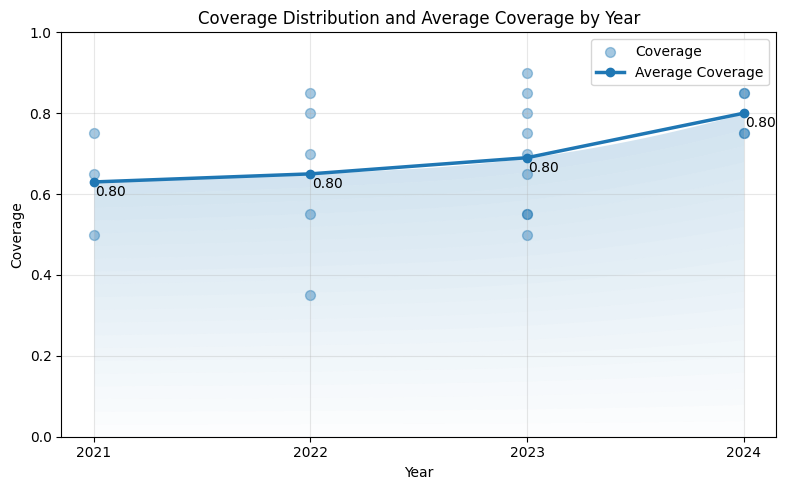

In [28]:
# =========================
# 3. 准备折线数据
# =========================
avg_df = (
    df.groupby("Year", as_index=False)["Avg Coverage"]
    .first()
    .sort_values("Year")
)

# =========================
# 4. 绘图
# =========================
plt.figure(figsize=(8, 5))

# 散点图：每个问题的 coverage
plt.scatter(
    df["Year"],
    df["Coverage"],
    alpha=0.4,
    s=50,
    label="Coverage"
)

# 折线图：每年平均 coverage
plt.plot(
    avg_df["Year"],
    avg_df["Avg Coverage"],
    linewidth=2.5,
    marker="o",
    label="Average Coverage"
)

# =========================
# 5. 图形美化
# =========================

for x, y in zip(avg_df["Year"], avg_df["Avg Coverage"]):
    plt.annotate(
    "0.80",
    (x, y),
    textcoords="offset points",
    xytext=(12,-10),
    ha='center',
)

base_color = "#1f77b4"  # matplotlib默认蓝（很稳）

n_layers = 20

for i in range(n_layers):
    alpha = 0.01 + 0.2 * (i / n_layers)  # 从浅到深
    y_lower = y_smooth * (i / n_layers)
    y_upper = y_smooth * ((i + 1) / n_layers)

    plt.fill_between(
        x_smooth,
        y_lower,
        y_upper,
        color=base_color,   # 👈 固定颜色
        alpha=alpha,
        linewidth=0
    )

plt.xlabel("Year")
plt.ylabel("Coverage")
plt.grid(axis='x', alpha=0.3)
plt.title("Coverage Distribution and Average Coverage by Year")
plt.xticks(sorted(df["Year"].dropna().unique()))
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


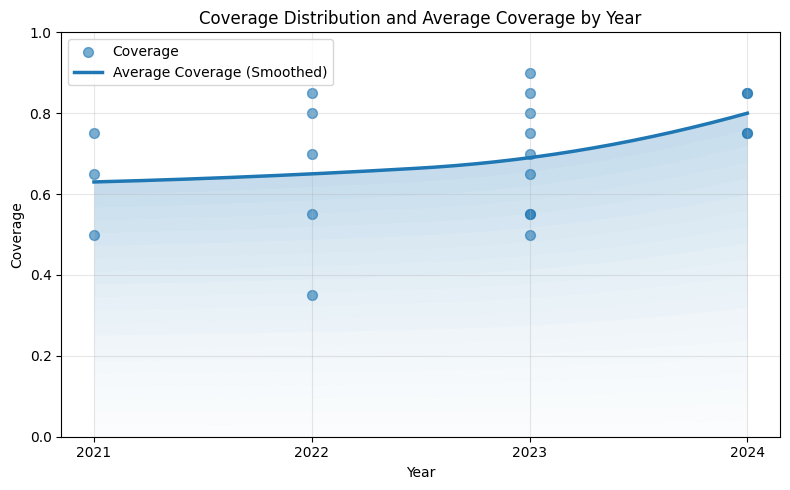

In [13]:
import numpy as np
from scipy.interpolate import make_interp_spline

# 原始数据
x = avg_df["Year"].values
y = avg_df["Avg Coverage"].values

plt.figure(figsize=(8, 5))

# 散点图：每个问题的 coverage
plt.scatter(
    df["Year"],
    df["Coverage"],
    alpha=0.6,
    s=50,
    label="Coverage"
)

# 生成更密的 x（让曲线变平滑）
x_smooth = np.linspace(x.min(), x.max(), 200)

# spline 插值
spline = make_interp_spline(x, y, k=2)  # k=2 比较稳（你数据点少）
y_smooth = spline(x_smooth)

# 画平滑曲线
plt.plot(
    x_smooth,
    y_smooth,
    linewidth=2.5,
    label="Average Coverage (Smoothed)"
)

# 画渐变填充
# 从下往上叠加）
n_layers = 20
base_color = "#1f77b4"  # matplotlib默认蓝（很稳）

for i in range(n_layers):
    alpha = 0.02 + 0.25 * (i / n_layers)**1.5  # 从浅到深
    y_lower = y_smooth * (i / n_layers)
    y_upper = y_smooth * ((i + 1) / n_layers)

    plt.fill_between(
        x_smooth,
        y_lower,
        y_upper,
        color=base_color,   # 👈 固定颜色
        alpha=alpha,
        linewidth=0
    )

plt.xlabel("Year")
plt.ylabel("Coverage")
plt.grid(axis='x', alpha=0.3)
plt.title("Coverage Distribution and Average Coverage by Year")
plt.xticks(sorted(df["Year"].dropna().unique()))
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
